# Analysis of Part Types and Image Categories
This notebook analyzes the relationship between part types (original, commentary, etc.) and image categories (Content Keywords) over 20-year intervals.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Setting the aesthetic style of the plots
sns.set_theme(style="whitegrid")

# Load the data
image_df = pd.read_csv('../DATA/02_image_clusters/full_image_data_feb_25.csv', low_memory=False)
book_df = pd.read_csv('../DATA/01_corpus_metadata/full_book_data_feb_25.csv', low_memory=False)

print(f"Image data loaded: {len(image_df)} rows")
print(f"Book data loaded: {len(book_df)} rows")

Image data loaded: 27981 rows
Book data loaded: 359 rows


## 1. Data Categorization and Cleaning
We will generalize the `type_label` into four main categories: original, commentary, related text, and other.

In [2]:
def categorize_part_type(label):
    if pd.isna(label):
        return 'other'
    label = str(label).lower()
    if 'original' in label:
        return 'original'
    elif 'annotated' in label or 'commentary' in label:
        return 'commentary'
    elif 'related' in label:
        return 'related text'
    else:
        return 'other'

image_df['text_part_category'] = image_df['type_label'].apply(categorize_part_type)

# Ensure year_interval and place_category are treated as ordered categories
intervals = sorted(image_df['year_interval'].dropna().unique())
image_df['year_interval'] = pd.Categorical(image_df['year_interval'], categories=intervals, ordered=True)
book_df['year_interval'] = pd.Categorical(book_df['year_interval'], categories=intervals, ordered=True)

place_cats = ['Large Center', 'Medium Center', 'Small Center', 'One Book Center']
image_df['place_category'] = pd.Categorical(image_df['place_category'], categories=place_cats, ordered=True)

image_df[['type_label', 'text_part_category', 'year_interval', 'place_category']].head(10)

,type_label,text_part_category,year_interval,place_category
0,"Content, Annotated",commentary,1470-1489,Large Center
1,"Content, Annotated",commentary,1470-1489,Large Center
2,"Content, Annotated",commentary,1470-1489,Large Center
3,"Original Part, Content",original,1470-1489,Large Center
4,"Original Part, Content",original,1470-1489,Large Center
5,"Original Part, Content",original,1470-1489,Large Center
6,"Original Part, Content",original,1470-1489,Large Center
7,"Original Part, Content",original,1470-1489,Large Center
8,"Original Part, Content",original,1470-1489,Large Center
9,"Original Part, Content",original,1470-1489,Large Center


## 2. Graph 1: Unique book values per part type over time
This graph shows how many unique books (by `bid`) contain each text part type across the 20-year intervals.
A black broken line represents the total number of books printed in the corpus in that period.

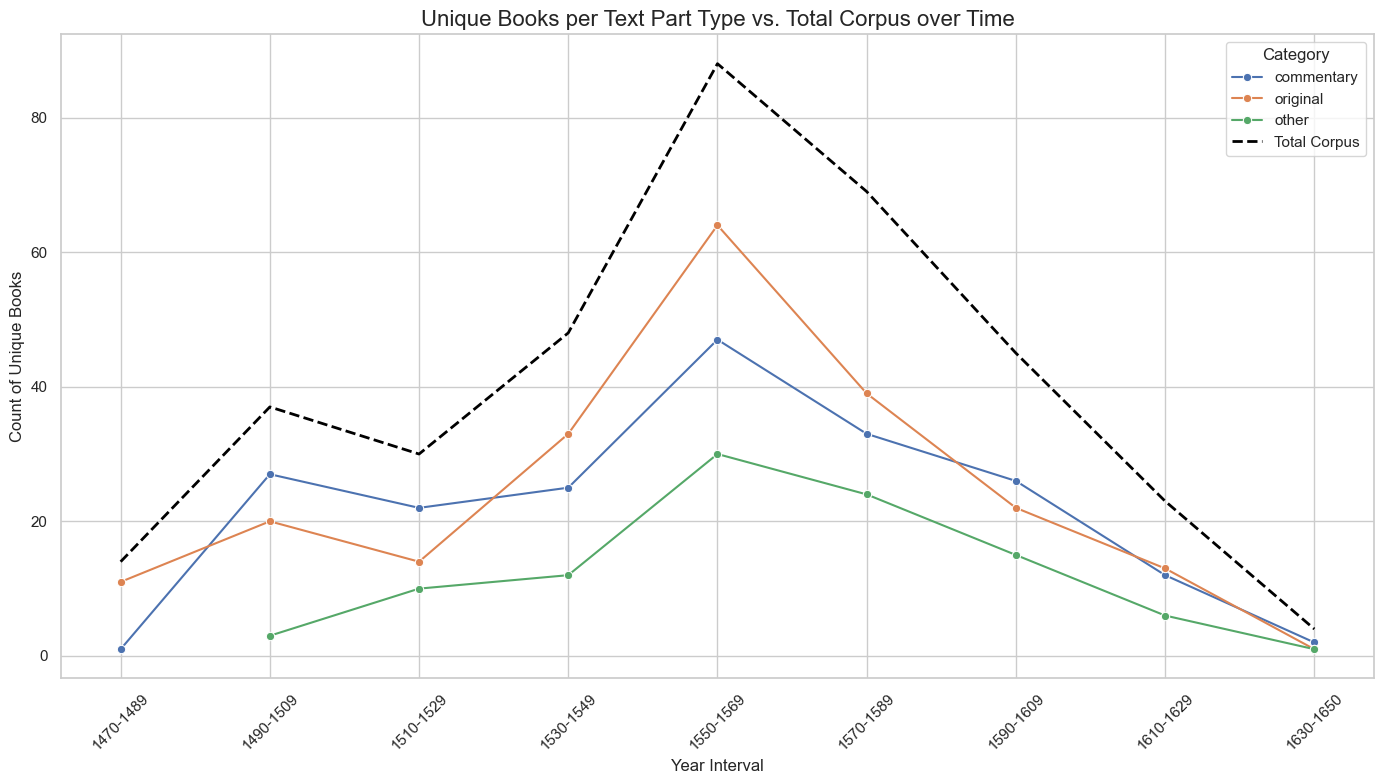

In [3]:
# Aggregating unique books per interval and part category
g1_data = image_df.groupby(['year_interval', 'text_part_category'], observed=True)['bid'].nunique().reset_index()
g1_data.rename(columns={'bid': 'unique_book_count'}, inplace=True)

# Calculating total books in the corpus per interval
total_books = book_df.groupby('year_interval', observed=True)['bid'].nunique().reset_index()
total_books.rename(columns={'bid': 'total_book_count'}, inplace=True)

plt.figure(figsize=(14, 8))
# Existing part type lines
sns.lineplot(data=g1_data, x='year_interval', y='unique_book_count', hue='text_part_category', marker='o')

# Adding the total line (black, broken)
sns.lineplot(data=total_books, x='year_interval', y='total_book_count', color='black', linestyle='--', linewidth=2, label='Total Corpus')

plt.title('Unique Books per Text Part Type vs. Total Corpus over Time', fontsize=16)
plt.xlabel('Year Interval', fontsize=12)
plt.ylabel('Count of Unique Books', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Category')
plt.tight_layout()
plt.show()

## 3. Graph 3: Proportion of Books with Original, Commentary, or Neither over Time
This graph shows the percentage of books in each interval that include original text, commentary, both, or neither (non of those).

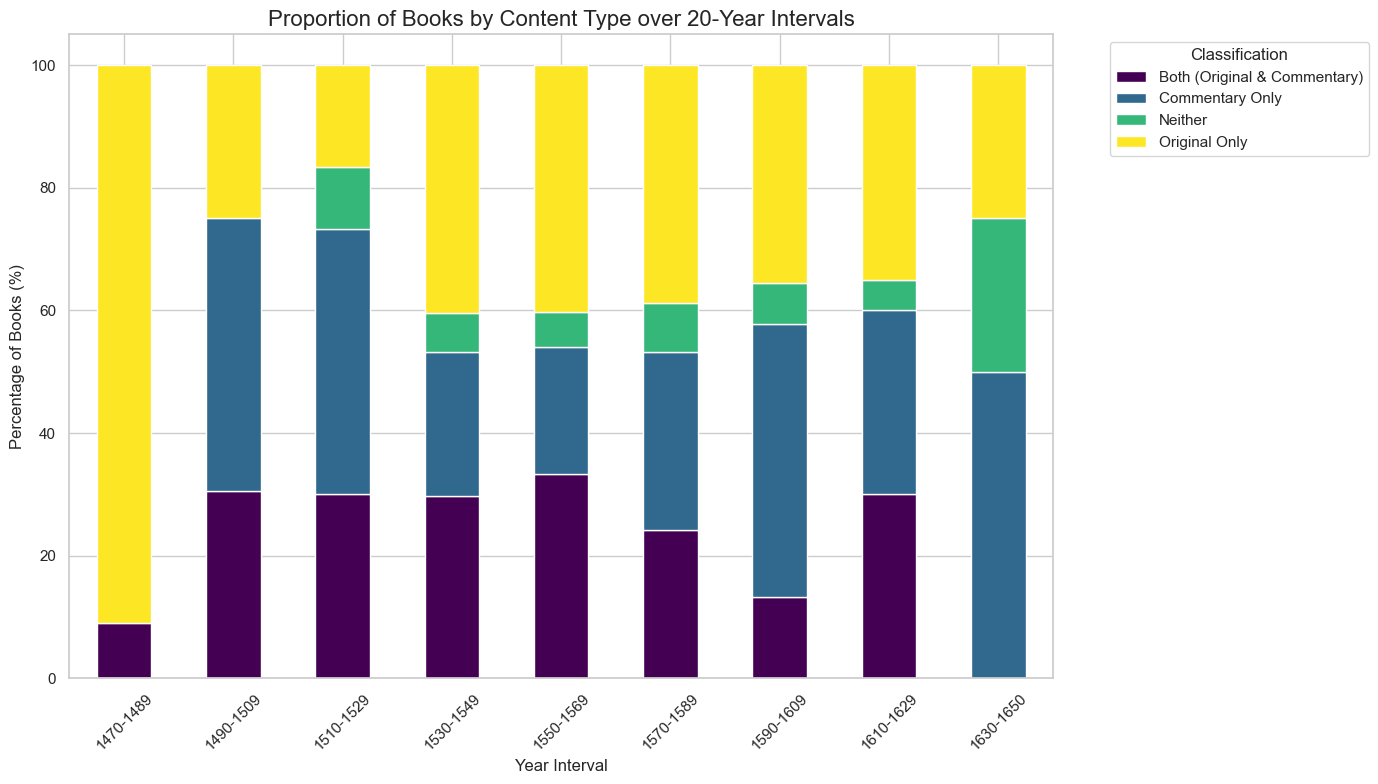

In [4]:
# For each book (bid) and interval, determine if it has original, commentary, or neither
book_parts = image_df.groupby(['bid', 'year_interval'], observed=True)['text_part_category'].unique().reset_index()

def classify_book(parts):
    has_orig = 'original' in parts
    has_comm = 'commentary' in parts
    if has_orig and has_comm:
        return 'Both (Original & Commentary)'
    elif has_orig:
        return 'Original Only'
    elif has_comm:
        return 'Commentary Only'
    else:
        return 'Neither'

book_parts['classification'] = book_parts['text_part_category'].apply(classify_book)

# Calculating proportions per interval
g3_counts = book_parts.groupby(['year_interval', 'classification'], observed=True)['bid'].count().unstack(fill_value=0)
g3_props = g3_counts.div(g3_counts.sum(axis=1), axis=0) * 100

# Plotting
g3_props.plot(kind='bar', stacked=True, figsize=(14, 8), cmap='viridis')

plt.title('Proportion of Books by Content Type over 20-Year Intervals', fontsize=16)
plt.xlabel('Year Interval', fontsize=12)
plt.ylabel('Percentage of Books (%)', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Classification', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 4. Graph 4: Proportion of Books by Content Type per Place Category
This graph shows the division of book types (Original, Commentary, Both, Neither) across different **Place Categories**.

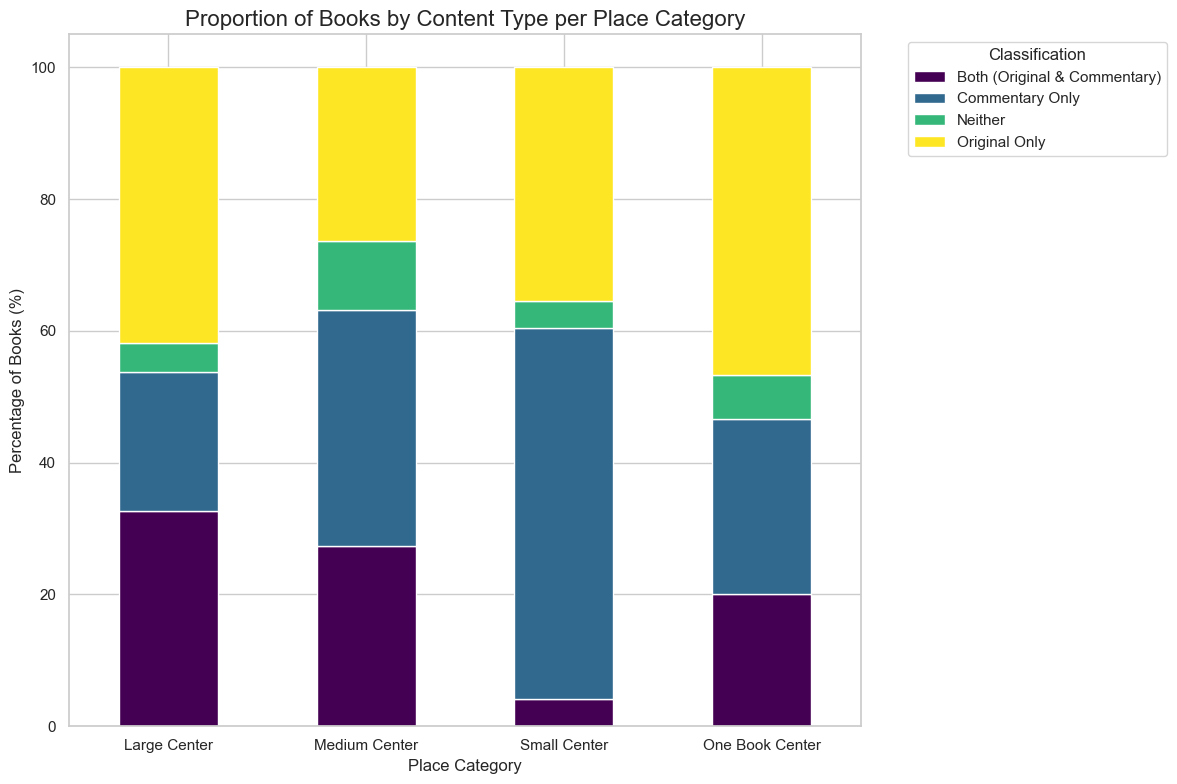

In [5]:
# Determine classification per book across place categories (assuming classification doesn't change for the same book ID)
book_place_parts = image_df.groupby(['bid', 'place_category'], observed=True)['text_part_category'].unique().reset_index()
book_place_parts['classification'] = book_place_parts['text_part_category'].apply(classify_book)

# Calculating proportions per place category
g4_counts = book_place_parts.groupby(['place_category', 'classification'], observed=True)['bid'].count().unstack(fill_value=0)
# Ensure sorting based on center size
g4_props = g4_counts.div(g4_counts.sum(axis=1), axis=0) * 100

# Plotting
g4_props.plot(kind='bar', stacked=True, figsize=(12, 8), cmap='viridis')

plt.title('Proportion of Books by Content Type per Place Category', fontsize=16)
plt.xlabel('Place Category', fontsize=12)
plt.ylabel('Percentage of Books (%)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Classification', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/corrections_round/text_part_place_cat.png', dpi=300)


plt.show()

## 5. Graph 2: Books with Original and Commentary vs. Place Category over Time
This graph compares how many books with **Original** text and **Commentary** were printed in each of the **Place Categories** over time.

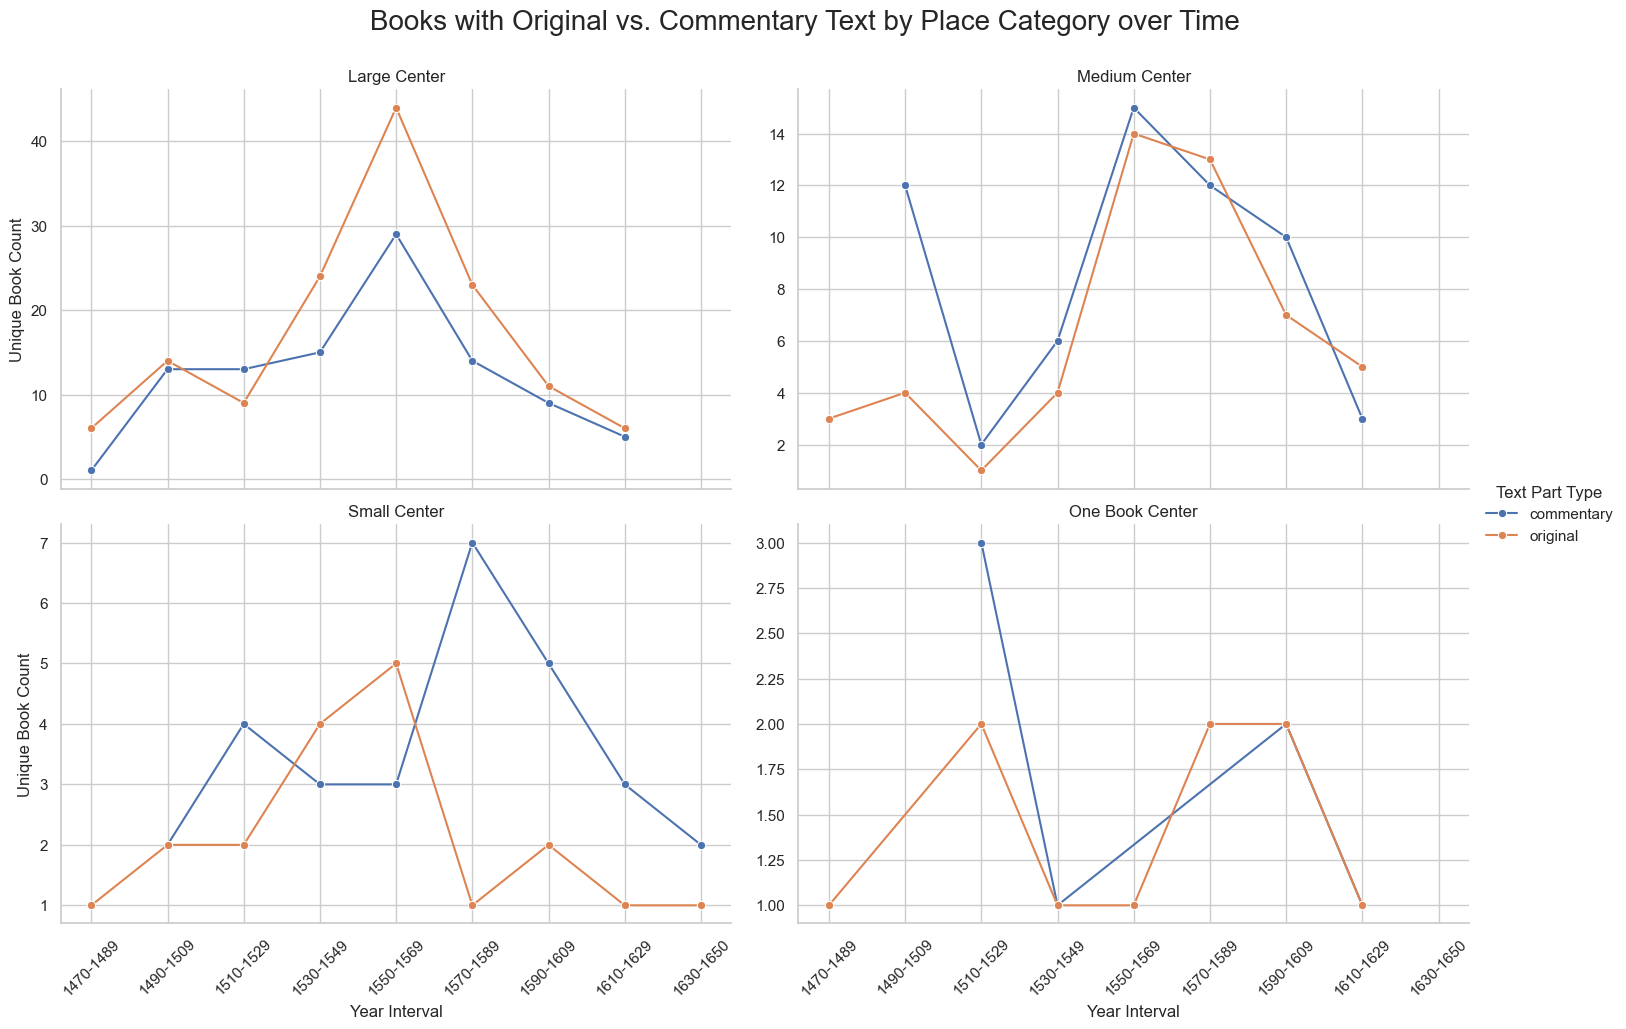

In [6]:
# Filter for only original and commentary categories
df_filtered = image_df[image_df['text_part_category'].isin(['original', 'commentary'])].copy()

# Aggregating unique books per interval, part category, and place category
g2_data = df_filtered.groupby(['year_interval', 'text_part_category', 'place_category'], observed=True)['bid'].nunique().reset_index()
g2_data.rename(columns={'bid': 'book_count'}, inplace=True)

# Plotting with a FacetGrid to compare per place category
g = sns.FacetGrid(g2_data, col="place_category", hue="text_part_category", col_wrap=2, height=5, aspect=1.5, sharey=False)
g.map(sns.lineplot, "year_interval", "book_count", marker='o')

g.set_axis_labels("Year Interval", "Unique Book Count")
g.add_legend(title="Text Part Type")
g.set_titles("{col_name}")

for ax in g.axes.flat:
    for label in ax.get_xticklabels():
        label.set_rotation(45)

plt.subplots_adjust(top=0.9)
g.fig.suptitle('Books with Original vs. Commentary Text by Place Category over Time', fontsize=20)
plt.show()

## 3. City-Level Analysis of Part Types
Which cities print the most by part type? We will analyze the Top 20 cities to see the composition of their scientific printing.

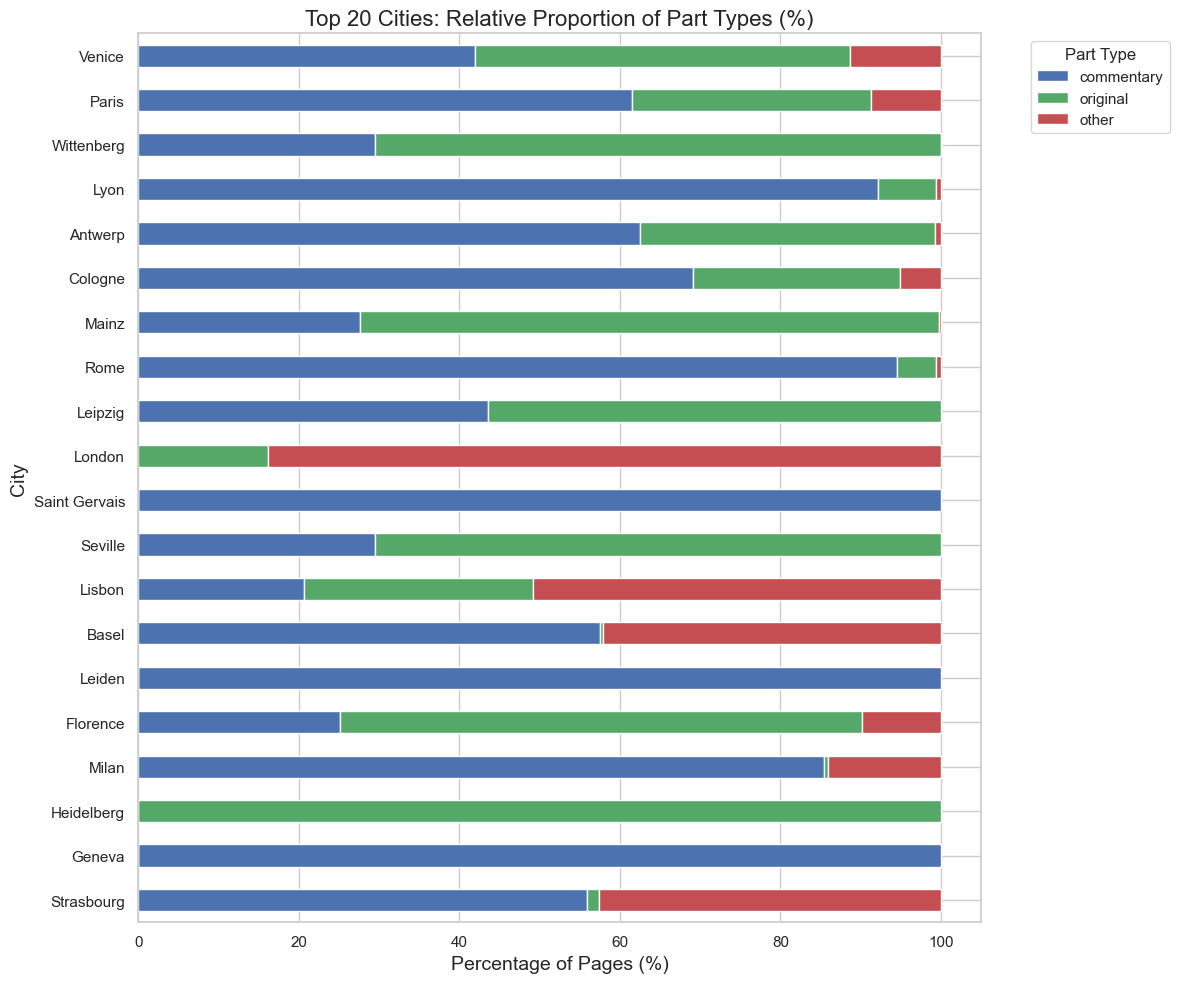

In [7]:

# Group by city and part type, also counting total for sorting
city_counts = image_df.groupby(['place', 'text_part_category']).size().unstack(fill_value=0)
city_counts['total'] = city_counts.sum(axis=1)

# Get Top 20 cities by total volume
top_20_cities = city_counts.sort_values(by='total', ascending=False).head(20)

# Normalize to percentages for relative comparison
plot_data_pct = top_20_cities.drop(columns='total').div(top_20_cities['total'], axis=0) * 100

# Plotting
ax = plot_data_pct.plot(kind='barh', stacked=True, figsize=(12, 10), 
                        color=['#4c72b0', '#55a868', '#c44e52', '#8172b2'])
plt.title('Top 20 Cities: Relative Proportion of Part Types (%)', fontsize=16)
plt.xlabel('Percentage of Pages (%)', fontsize=14)
plt.ylabel('City', fontsize=14)
plt.legend(title='Part Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.gca().invert_yaxis()  # Put the biggest city on top
plt.tight_layout()
plt.show()


## 4. Part Types by Center Category (Large vs Small Centers)
Does the type of printing center (Large Center, Medium, etc.) correlate with the type of text being printed?

/var/folders/6r/8tpplrhn0rlglqf49qymjfmc0000gn/T/ipykernel_3452/2798404367.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cat_counts = image_df.groupby(['place_category', 'text_part_category']).size().unstack(fill_value=0)


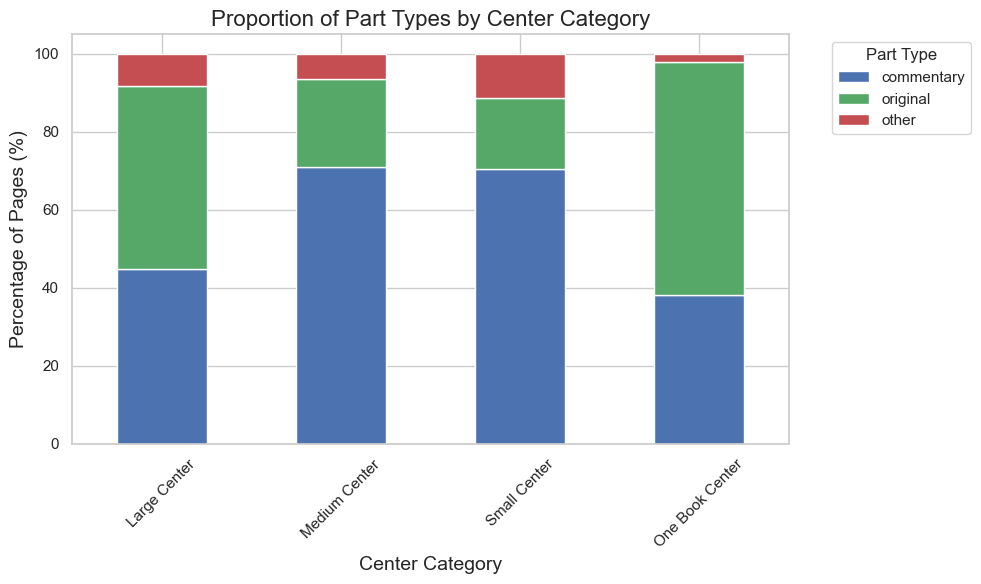

In [8]:

# Group by place_category and text_part_category
cat_counts = image_df.groupby(['place_category', 'text_part_category']).size().unstack(fill_value=0)

# Normalize to percentages to see proportions clearly
cat_pct = cat_counts.div(cat_counts.sum(axis=1), axis=0) * 100

# Plotting percentages
ax = cat_pct.plot(kind='bar', stacked=True, figsize=(10, 6), 
                   color=['#4c72b0', '#55a868', '#c44e52', '#8172b2'])
plt.title('Proportion of Part Types by Center Category', fontsize=16)
plt.ylabel('Percentage of Pages (%)', fontsize=14)
plt.xlabel('Center Category', fontsize=14)
plt.legend(title='Part Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



## 5. Top Cities Specialize by Part Type
Which cities have the highest *percentage* of each type (among cities with at least 100 pages)?


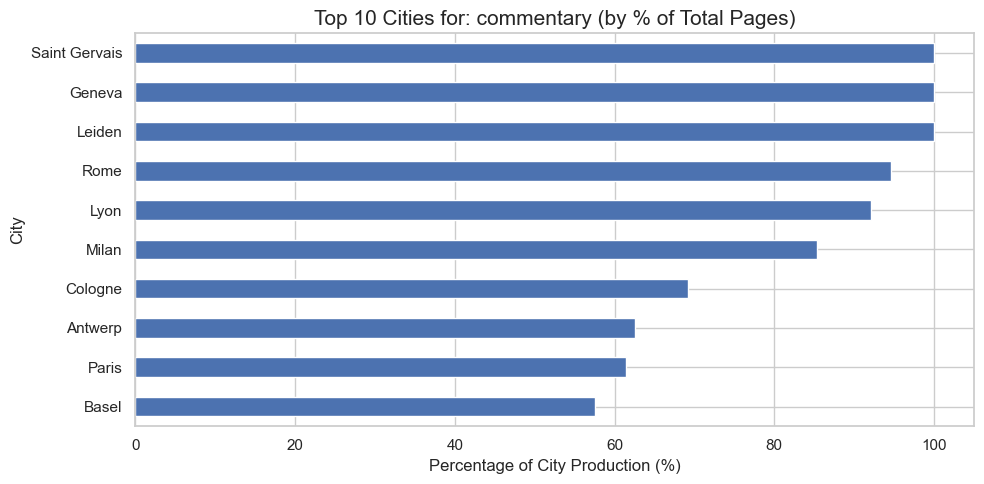

------------------------------


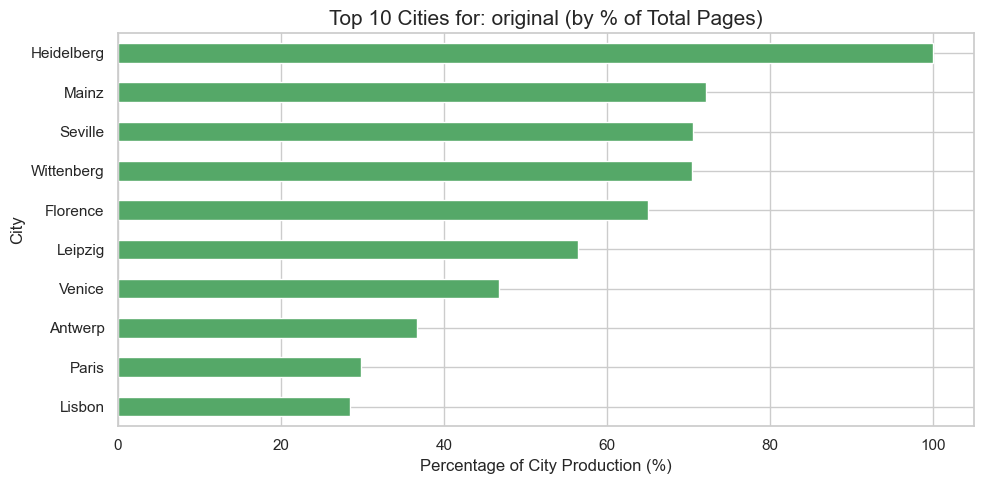

------------------------------


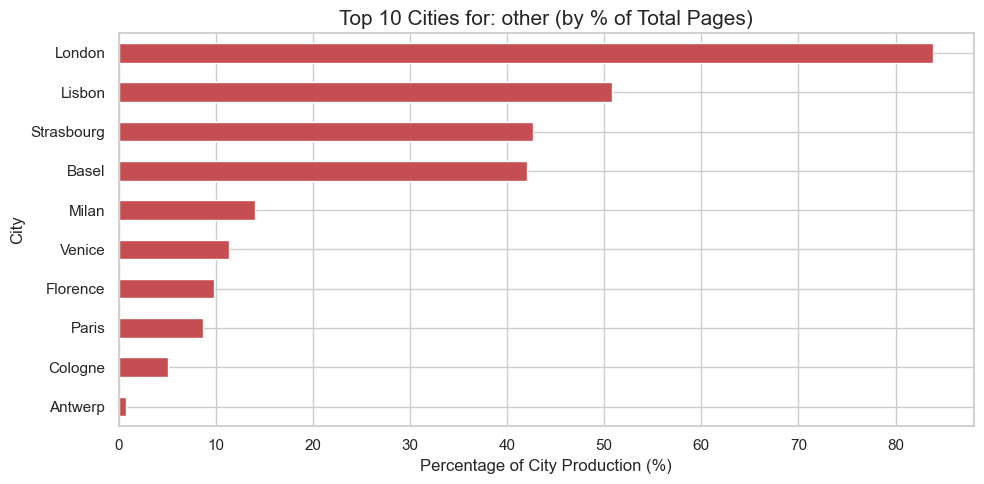

------------------------------


In [9]:

# 1. Prepare data
city_full_counts = image_df.groupby(['place', 'text_part_category']).size().unstack(fill_value=0)
city_full_counts['total'] = city_full_counts.sum(axis=1)

# Filter for cities with at least 100 total pages to ensure relevance
significant_cities = city_full_counts[city_full_counts['total'] >= 100].copy()

# 2. Plot for each category
categories = [c for c in significant_cities.columns if c != 'total']
colors = ['#4c72b0', '#55a868', '#c44e52', '#8172b2', '#ccb974', '#64b5cd']

for i, cat in enumerate(categories):
    # Calculate percentage for this category
    significant_cities[f'{cat}_pct'] = (significant_cities[cat] / significant_cities['total']) * 100
    
    # Sort and get top 10
    top_specialized = significant_cities.sort_values(f'{cat}_pct', ascending=False).head(10)
    
    # Plot
    plt.figure(figsize=(10, 5))
    top_specialized[f'{cat}_pct'].plot(kind='barh', color=colors[i % len(colors)])
    plt.title(f'Top 10 Cities for: {cat} (by % of Total Pages)', fontsize=15)
    plt.xlabel('Percentage of City Production (%)', fontsize=12)
    plt.ylabel('City', fontsize=12)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    print("-" * 30)



## 6. Cities with Single Part-Type Focus
Are there cities that printed only one type of text? This analysis identifies cities that show a 100% concentration in a single category.


Specialist Cities (100% focus on one part type, with >= 20 pages):


,text_part_category,page_count
place,,
Saint Gervais,commentary,379
Leiden,commentary,209
Heidelberg,original,153
Geneva,commentary,148
Coimbra,original,80
Neustadt an der Weinstraße,original,80
Kraków,commentary,75
Vienna,original,69
Ingolstadt,commentary,66


/var/folders/6r/8tpplrhn0rlglqf49qymjfmc0000gn/T/ipykernel_3452/611548151.py:19: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(data=specialist_cities.reset_index().head(15), x='page_count', y='place', hue='text_part_category', palette=['#55a868', '#4c72b0'])


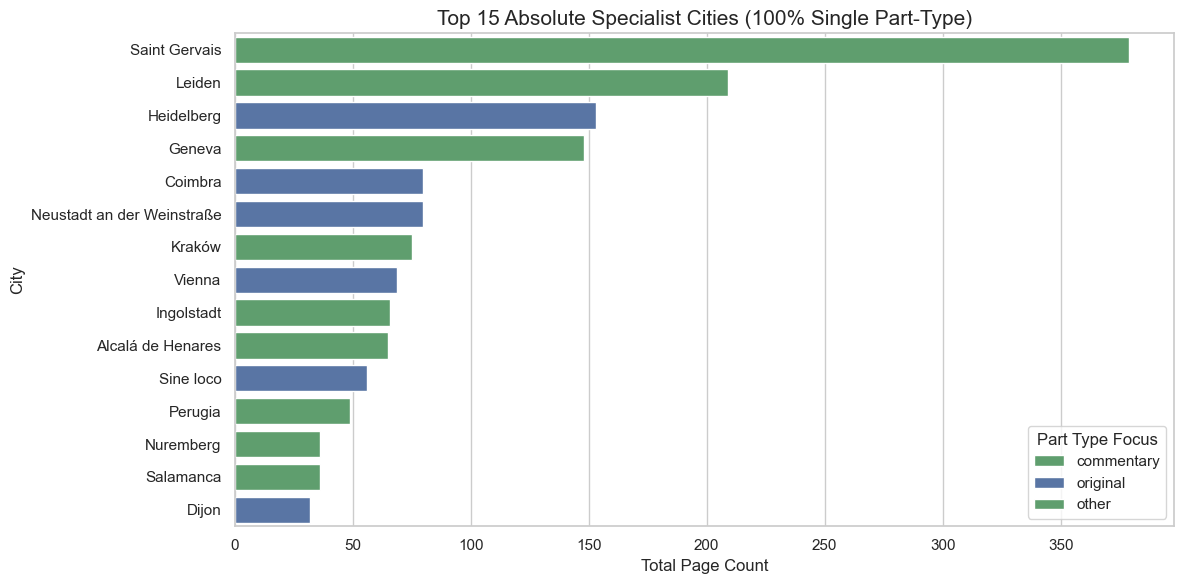

In [10]:

# 1. Identify cities with only one unique part type
city_variety = image_df.groupby('place')['text_part_category'].nunique()
single_type_cities = city_variety[city_variety == 1].index

# 2. Extract details and filter for volume
single_type_details = image_df[image_df['place'].isin(single_type_cities)].groupby('place').agg({
    'text_part_category': 'first',
    'place': 'count'
}).rename(columns={'place': 'page_count'})

# Filter for meaningful volume (at least 20 pages)
specialist_cities = single_type_details[single_type_details['page_count'] >= 20].sort_values('page_count', ascending=False)

print("Specialist Cities (100% focus on one part type, with >= 20 pages):")
display(specialist_cities)

# 3. Summary Visualization
plt.figure(figsize=(12, 6))
sns.barplot(data=specialist_cities.reset_index().head(15), x='page_count', y='place', hue='text_part_category', palette=['#55a868', '#4c72b0'])
plt.title('Top 15 Absolute Specialist Cities (100% Single Part-Type)', fontsize=15)
plt.xlabel('Total Page Count', fontsize=12)
plt.ylabel('City', fontsize=12)
plt.legend(title='Part Type Focus')
plt.tight_layout()
plt.show()


## 6. Graph 5: Temporal Evolution of Book Content Types
This graph follows the book-level criteria used in Graph 3, tracking the number of unique books per content type classification over time as a line graph.

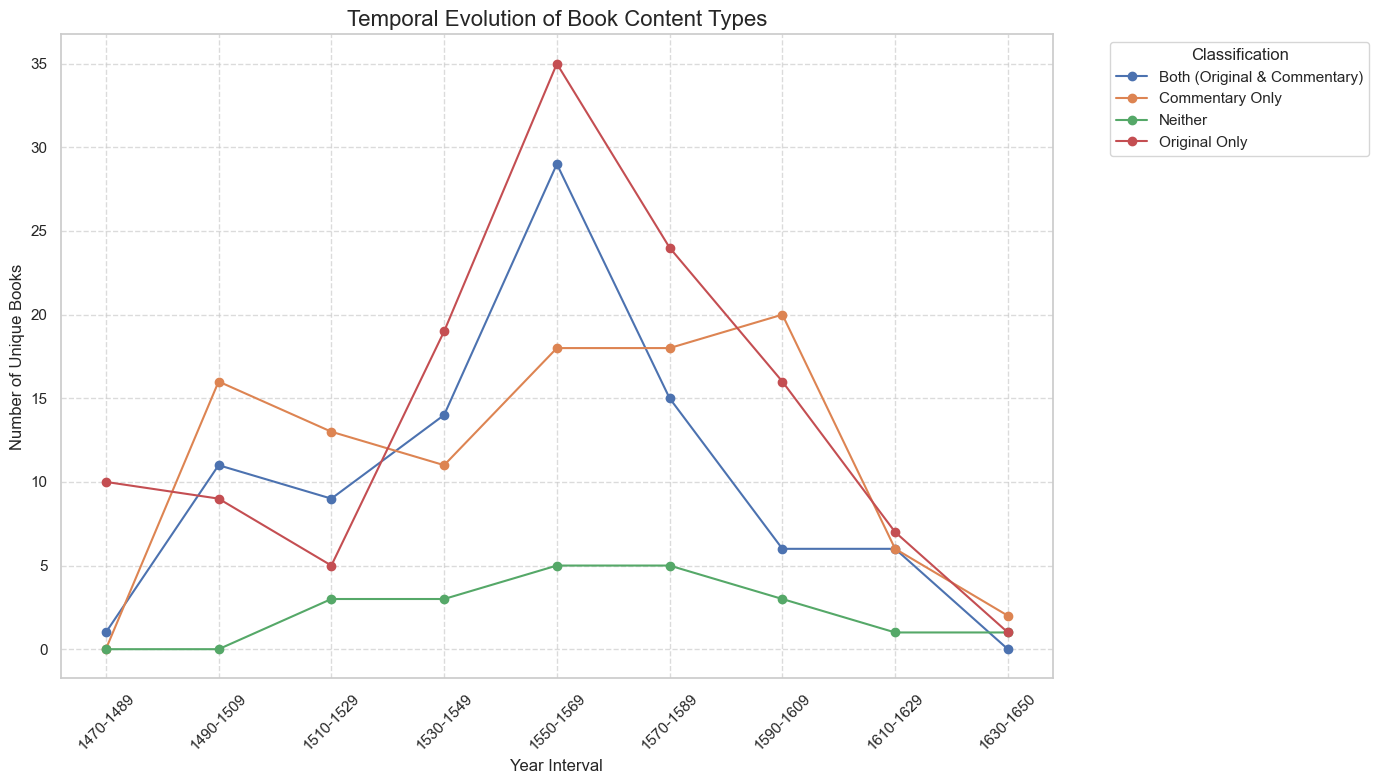

In [11]:
# Calculating counts per interval for line graph
g5_counts = book_parts.groupby(['year_interval', 'classification'], observed=True)['bid'].count().unstack(fill_value=0)

# Plotting as a line graph
plt.figure(figsize=(14, 8))
for column in g5_counts.columns:
    plt.plot(g5_counts.index.astype(str), g5_counts[column], marker='o', label=column)

plt.title('Temporal Evolution of Book Content Types', fontsize=16)
plt.xlabel('Year Interval', fontsize=12)
plt.ylabel('Number of Unique Books', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Classification', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/corrections_round/text_part_time.png', dpi=300)

plt.show()

## 7. City-Level Content Type Distribution Table
This table shows the number and percentage of unique editions (books) for each content type classification, grouped by city and place category.

In [12]:
# Mapping book classification to city and place category
book_metadata = image_df.groupby('bid', observed=True).agg({
    'place': 'first',
    'place_category': 'first'
}).reset_index()

city_types = pd.merge(book_parts[['bid', 'classification']], book_metadata, on='bid')

# Aggregating counts
city_summary = city_types.groupby(['place_category', 'place', 'classification'], observed=True).size().unstack(fill_value=0)

# Calculate Total Editions
city_summary['Total Editions'] = city_summary.sum(axis=1)

# Calculate Percentages
classifications = ['Both (Original & Commentary)', 'Original Only', 'Commentary Only', 'Neither']
for col in classifications:
    if col in city_summary.columns:
        city_summary[f'{col} (%)'] = (city_summary[col] / city_summary['Total Editions'] * 100).round(2)

# Reorder columns: Total Editions first, then counts, then percentages
count_cols = [c for c in city_summary.columns if '%' not in c and c != 'Total Editions']
perc_cols = [c for c in city_summary.columns if '%' in c]
city_summary = city_summary[['Total Editions'] + count_cols + perc_cols]

# Sort by place category and volume
city_summary = city_summary.sort_values(['place_category', 'Total Editions'], ascending=[True, False])

# Display the summary table
from IPython.display import display
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(city_summary)

classification                              Total Editions  \
place_category  place                                        
Large Center    Paris                                   68   
                Venice                                  68   
                Wittenberg                              48   
Medium Center   Antwerp                                 22   
                Leipzig                                 19   
                Lyon                                    16   
                Cologne                                 15   
                Frankfurt (Main)                        13   
                London                                  10   
Small Center    Rome                                     6   
                Seville                                  5   
                Strasbourg                               5   
                Leiden                                   4   
                Florence                                 3   
                Kraków                                   3   
                Lisbon                                   3   
                Saint Gervais                            3   
                Basel                                    2   
                Dijon                                    2   
                Milan                                    2   
                Perugia                                  2   
                Sine loco                                2   
                Valladolid                               2   
                Bologna                                  1   
                Lemgo                                    1   
                Madrid                                   1   
                Salamanca                                1   
One Book Center Alcalá de Henares                        1   
                Avignon                                  1   
                Coimbra                                  1   
                Ferrara                                  1   
                Geneva                                   1   
                Heidelberg                               1   
                Ingolstadt                               1   
                Leuven                                   1   
                Mainz                                    1   
                Mexico City                              1   
                Neustadt an der Weinstraße               1   
                Nuremberg                                1   
                Padua                                    1   
                Siena                                    1   
                Vienna                                   1   

classification                              Both (Original & Commentary)  \
place_category  place                                                      
Large Center    Paris                                                 26   
                Venice                                                20   
                Wittenberg                                            14   
Medium Center   Antwerp                                               11   
                Leipzig                                                1   
                Lyon                                                   8   
                Cologne                                                6   
                Frankfurt (Main)                                       0   
                London                                                 0   
Small Center    Rome                                                   0   
                Seville                                                0   
                Strasbourg                                             0   
                Leiden                                                 0   
                Florence                                               0   
                Kraków                                 

## 8. Original Treatise Presence by City
This section analyzes cities based on the percentage of editions that include the original treatise vs. those that do not. 
*   **With Original Treatise**: Books classified as 'Both (Original & Commentary)' or 'Original Only'.
*   **Without Original Treatise**: Books classified as 'Commentary Only' or 'Neither'.

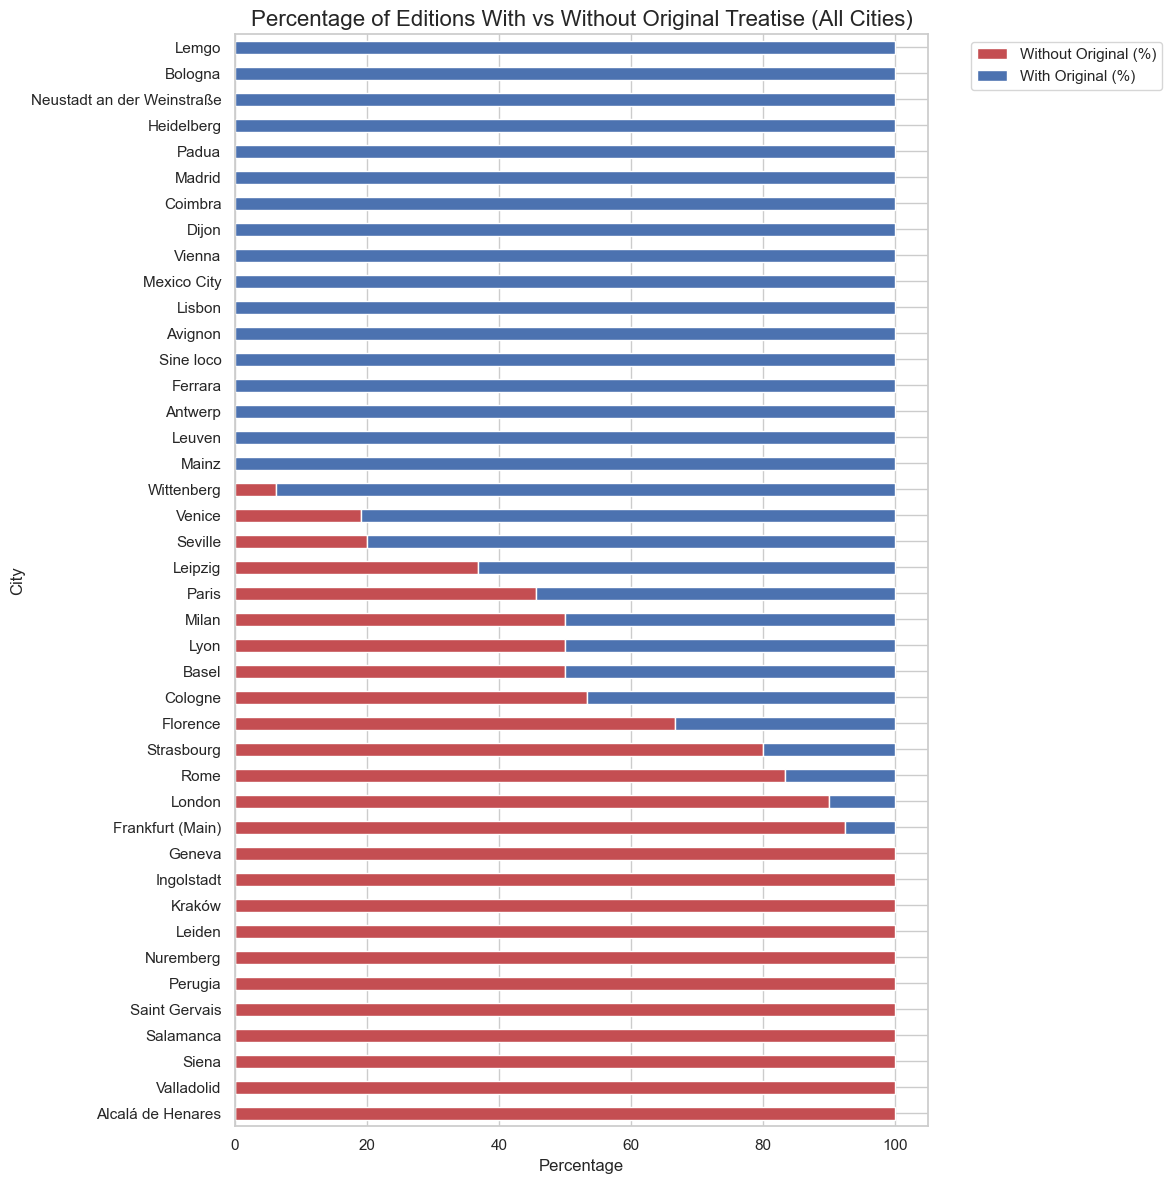

In [13]:
# 8a. Binary classification and Plotting: With vs Without Original Treatise
city_types['has_original'] = city_types['classification'].isin(['Both (Original & Commentary)', 'Original Only'])

treatise_summary = city_types.groupby(['place', 'has_original'], observed=True).size().unstack(fill_value=0)
treatise_summary.columns = ['Without Original', 'With Original']
treatise_summary['Total Editions'] = treatise_summary.sum(axis=1)
treatise_summary['With Original (%)'] = (treatise_summary['With Original'] / treatise_summary['Total Editions'] * 100).round(2)
treatise_summary['Without Original (%)'] = (treatise_summary['Without Original'] / treatise_summary['Total Editions'] * 100).round(2)

plot_df = treatise_summary.sort_values('With Original (%)', ascending=True)

ax = plot_df[['Without Original (%)', 'With Original (%)']].plot(
    kind='barh', stacked=True, figsize=(12, 12), color=['#c44e52', '#4c72b0']
)
plt.title('Percentage of Editions With vs Without Original Treatise (All Cities)', fontsize=16)
plt.xlabel('Percentage', fontsize=12)
plt.ylabel('City', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [14]:
# 8b. Detailed List of Treatise Presence by City
from IPython.display import display
with pd.option_context('display.max_rows', None):
    display(treatise_summary.sort_values('With Original (%)', ascending=False))

,Without Original,With Original,Total Editions,With Original (%),Without Original (%)
place,,,,,
Madrid,0,1,1,100.00,0.00
Sine loco,0,2,2,100.00,0.00
Lisbon,0,3,3,100.00,0.00
Neustadt an der Weinstraße,0,1,1,100.00,0.00
Padua,0,1,1,100.00,0.00
Heidelberg,0,1,1,100.00,0.00
Mainz,0,1,1,100.00,0.00
Mexico City,0,1,1,100.00,0.00
Ferrara,0,1,1,100.00,0.00


## 9. Content Type Specialization by City (Scatter Plots)
This section identifies cities that have the highest concentration of specific content types (Commentary Only, Original Only, or Both) and examines their distribution over place categories. All cities are included regardless of production volume.

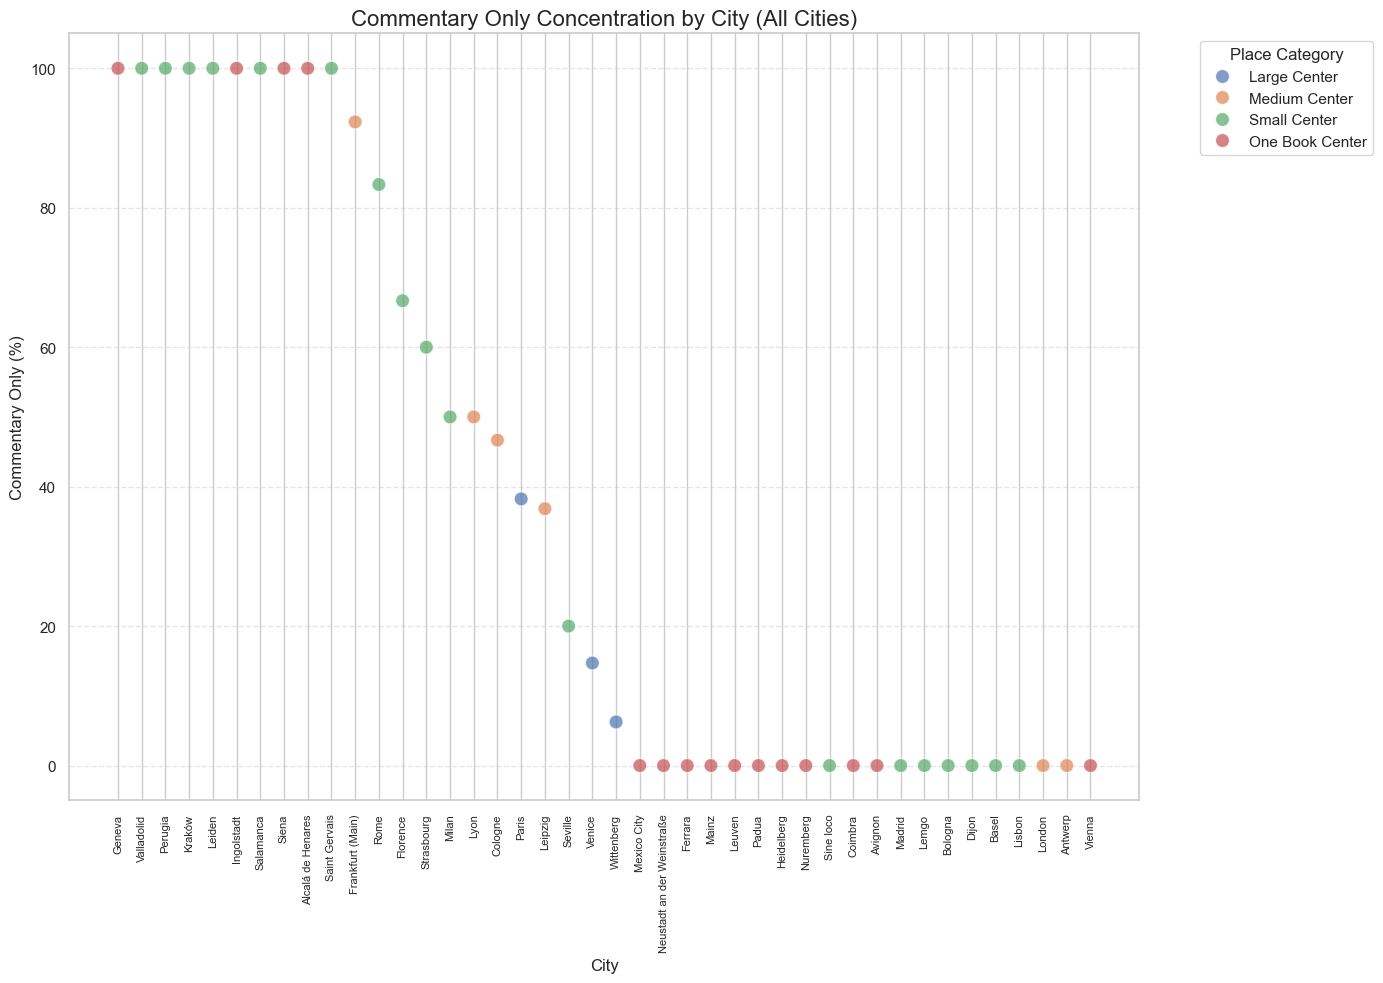

The prominent place category for cities printing any commentaries is: Small Center


In [15]:
# Analysis: Commentary Only Concentration (All Cities)
commentary_all = city_summary.reset_index().copy()
commentary_all = commentary_all.sort_values('Commentary Only (%)', ascending=False)

# Visualization: Scatter plot of all cities by Commentary Only percentage
plt.figure(figsize=(14, 10))
sns.scatterplot(
    data=commentary_all, 
    x='place', 
    y='Commentary Only (%)', 
    hue='place_category', 
    s=100, 
    alpha=0.7
)
plt.title('Commentary Only Concentration by City (All Cities)', fontsize=16)
plt.xlabel('City', fontsize=12)
plt.ylabel('Commentary Only (%)', fontsize=12)
plt.xticks(rotation=90, fontsize=8)
plt.legend(title='Place Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/corrections_round/cities_commentary.png', dpi=300)


plt.show()

# Calculate prominent place category over all cities
prominent_cat = commentary_all['place_category'].mode().values[0]
print(f"The prominent place category for cities printing any commentaries is: {prominent_cat}")

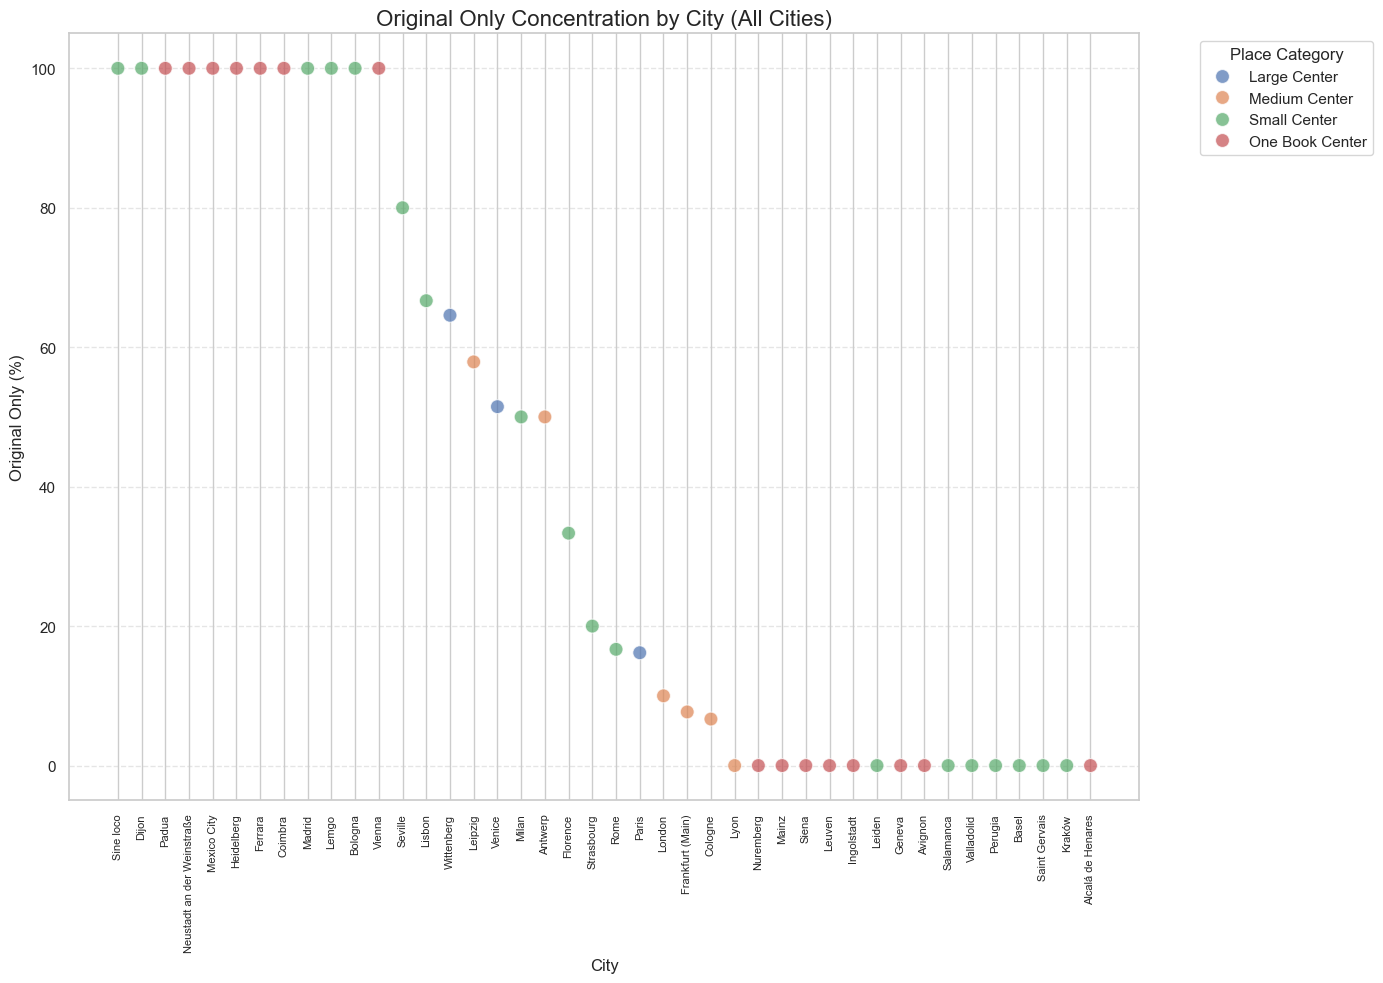

In [16]:
# Analysis: Original Only Concentration (All Cities)
original_all = city_summary.reset_index().copy()
original_all = original_all.sort_values('Original Only (%)', ascending=False)

# Visualization: Scatter plot of all cities by Original Only percentage
plt.figure(figsize=(14, 10))
sns.scatterplot(
    data=original_all, 
    x='place', 
    y='Original Only (%)', 
    hue='place_category', 
    s=100, 
    alpha=0.7
)
plt.title('Original Only Concentration by City (All Cities)', fontsize=16)
plt.xlabel('City', fontsize=12)
plt.ylabel('Original Only (%)', fontsize=12)
plt.xticks(rotation=90, fontsize=8)
plt.legend(title='Place Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/corrections_round/cities_original.png', dpi=300)


plt.show()


In [17]:
# Analysis: Both (Original & Commentary) Concentration (All Cities)
both_all = city_summary.reset_index().copy()
both_all = both_all.sort_values('Both (%)', ascending=False)

# Visualization: Scatter plot of all cities by Both percentage
plt.figure(figsize=(14, 10))
sns.scatterplot(
    data=both_all, 
    x='place', 
    y='Both (%)', 
    hue='place_category', 
    s=100, 
    alpha=0.7
)
plt.title('Both (Original & Commentary) Concentration by City (All Cities)', fontsize=16)
plt.xlabel('City', fontsize=12)
plt.ylabel('Both (%)', fontsize=12)
plt.xticks(rotation=90, fontsize=8)
plt.legend(title='Place Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


KeyError: 'Both (%)'

## 10. Frequency Distribution of Commentary Concentration
This section analyzes how many cities fall into specific ranges of 'Commentary Only' production (e.g., 0-20%, 20-40%, etc.) and identifies the dominant place categories within each range.

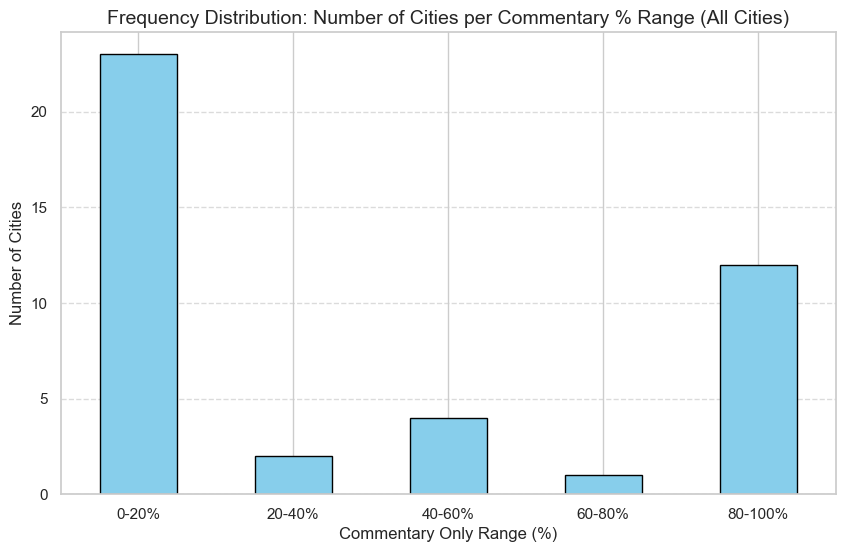

In [18]:
# 10a. Frequency Distribution: Number of Cities per Commentary % Range
dist_df = city_summary.copy().reset_index()
bins = [0, 20, 40, 60, 80, 100]
labels = ['0-20%', '20-40%', '40-60%', '60-80%', '80-100%']
dist_df['Commentary Range'] = pd.cut(dist_df['Commentary Only (%)'], bins=bins, labels=labels, include_lowest=True)

range_counts = dist_df.groupby('Commentary Range', observed=True).size()

plt.figure(figsize=(10, 6))
range_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Frequency Distribution: Number of Cities per Commentary % Range (All Cities)', fontsize=14)
plt.xlabel('Commentary Only Range (%)', fontsize=12)
plt.ylabel('Number of Cities', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


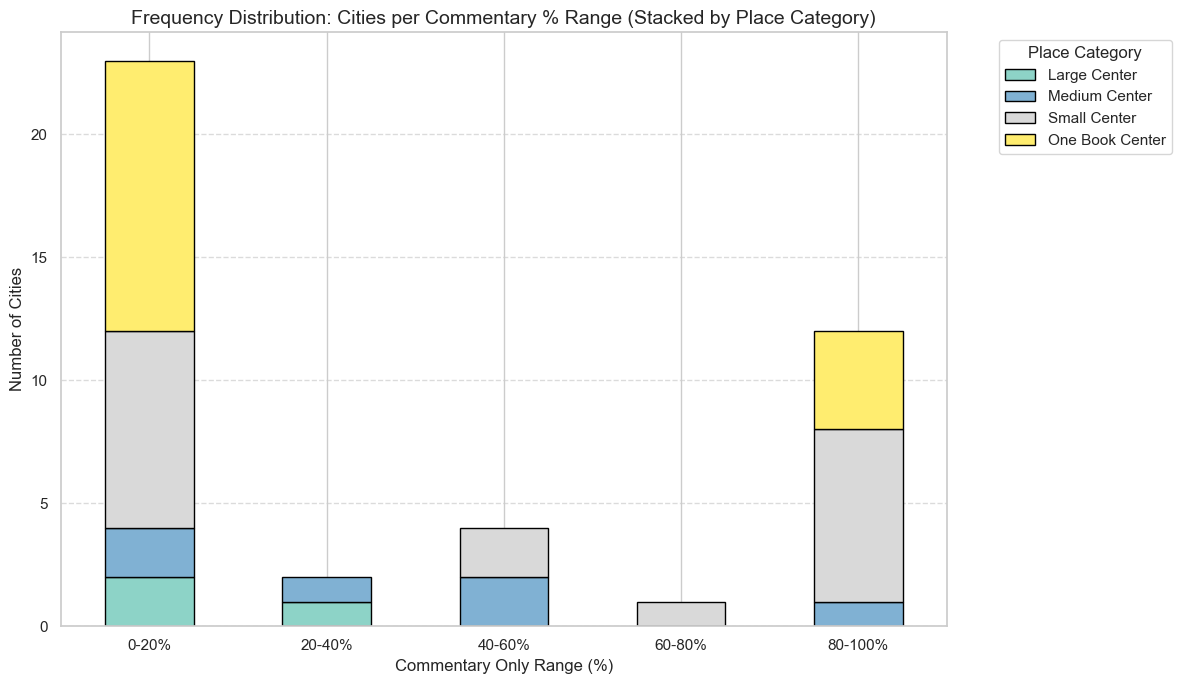

In [19]:
# 10b. Frequency Distribution: Number of Cities per Commentary % Range (Stacked by Place Category)
dist_df = city_summary.copy().reset_index()
bins = [0, 20, 40, 60, 80, 100]
labels = ['0-20%', '20-40%', '40-60%', '60-80%', '80-100%']
dist_df['Commentary Range'] = pd.cut(dist_df['Commentary Only (%)'], bins=bins, labels=labels, include_lowest=True)

# Count cities per range and place category
range_counts = dist_df.groupby(['Commentary Range', 'place_category'], observed=True).size().unstack(fill_value=0)

# Plotting as a stacked bar chart
plt.figure(figsize=(12, 7))
range_counts.plot(kind='bar', stacked=True, edgecolor='black', colormap='Set3', ax=plt.gca())

plt.title('Frequency Distribution: Cities per Commentary % Range (Stacked by Place Category)', fontsize=14)
plt.xlabel('Commentary Only Range (%)', fontsize=12)
plt.ylabel('Number of Cities', fontsize=12)
plt.legend(title='Place Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

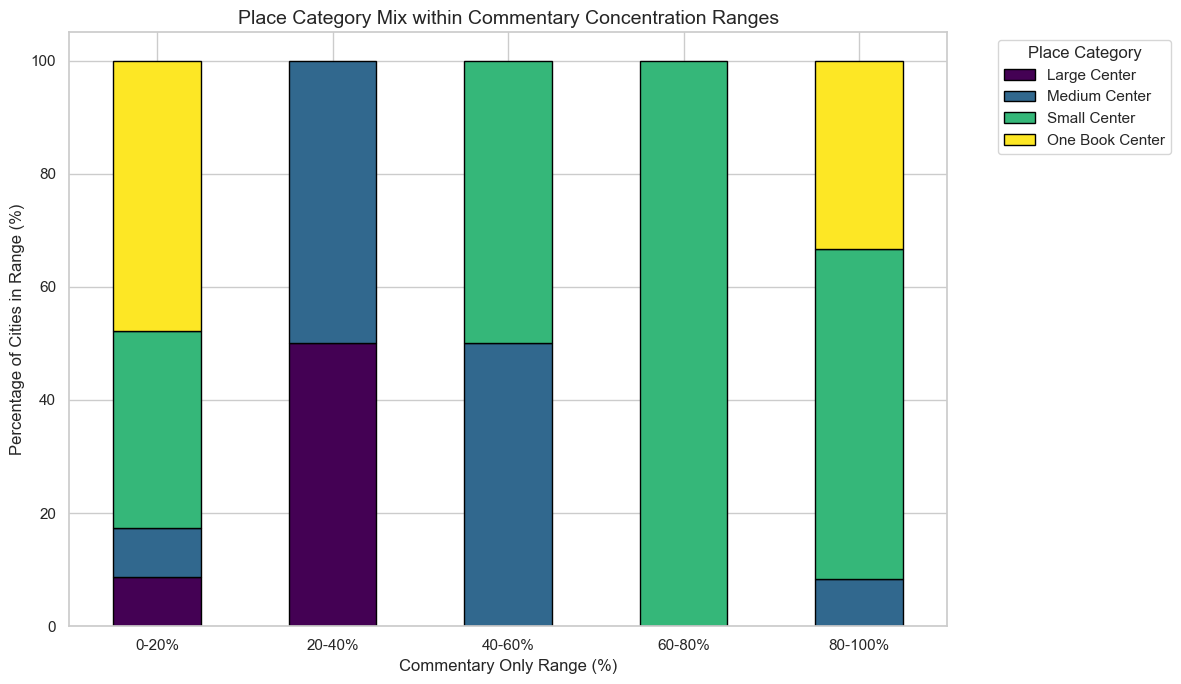

In [20]:
# 10b. Place Category Mix within Commentary Concentration Ranges
cat_dist = dist_df.groupby(['Commentary Range', 'place_category'], observed=True).size().unstack(fill_value=0)
cat_dist_perc = cat_dist.div(cat_dist.sum(axis=1), axis=0) * 100

ax = cat_dist_perc.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='viridis', edgecolor='black')
plt.title('Place Category Mix within Commentary Concentration Ranges', fontsize=14)
plt.xlabel('Commentary Only Range (%)', fontsize=12)
plt.ylabel('Percentage of Cities in Range (%)', fontsize=12)
plt.legend(title='Place Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [21]:
# 10d. Detailed Summary List of Cities by Commentary Range
display_cols = ['Commentary Range', 'place', 'place_category', 'Commentary Only (%)', 'Total Editions']
summary_list = dist_df[display_cols].sort_values(['Commentary Range', 'Commentary Only (%)'], ascending=[False, False])
with pd.option_context('display.max_rows', None, 'display.width', 1000):
    from IPython.display import display
    display(summary_list)

classification,Commentary Range,place,place_category,Commentary Only (%),Total Editions
12,80-100%,Leiden,Small Center,100.00,4
14,80-100%,Kraków,Small Center,100.00,3
16,80-100%,Saint Gervais,Small Center,100.00,3
20,80-100%,Perugia,Small Center,100.00,2
22,80-100%,Valladolid,Small Center,100.00,2
26,80-100%,Salamanca,Small Center,100.00,1
27,80-100%,Alcalá de Henares,One Book Center,100.00,1
31,80-100%,Geneva,One Book Center,100.00,1
33,80-100%,Ingolstadt,One Book Center,100.00,1
40,80-100%,Siena,One Book Center,100.00,1


## 11. Frequency Distribution of Original Only Concentration
This section analyzes the distribution of cities based on their percentage of 'Original Only' editions.

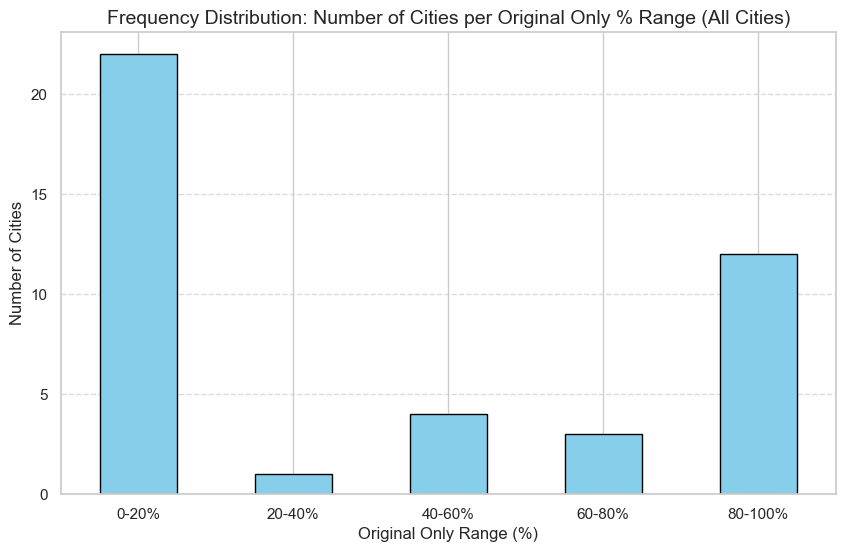

In [22]:
# 11a. Frequency Distribution: Number of Cities per Original Only % Range
dist_df_orig = city_summary.copy().reset_index()
bins = [0, 20, 40, 60, 80, 100]
labels = ['0-20%', '20-40%', '40-60%', '60-80%', '80-100%']
dist_df_orig['Original Only Range'] = pd.cut(dist_df_orig['Original Only (%)'], bins=bins, labels=labels, include_lowest=True)

range_counts_orig_simple = dist_df_orig.groupby('Original Only Range', observed=True).size()

plt.figure(figsize=(10, 6))
range_counts_orig_simple.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Frequency Distribution: Number of Cities per Original Only % Range (All Cities)', fontsize=14)
plt.xlabel('Original Only Range (%)', fontsize=12)
plt.ylabel('Number of Cities', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


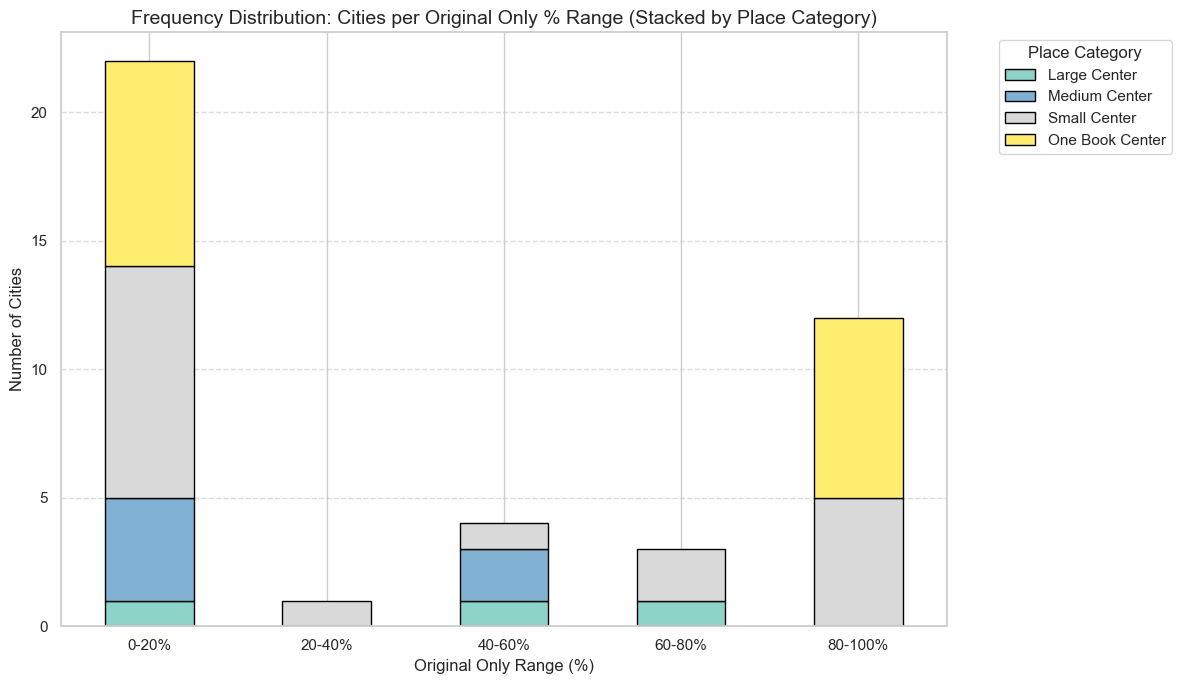

In [23]:
# 11b. Frequency Distribution: Cities per Original Only % Range
dist_df_orig = city_summary.copy().reset_index()
bins = [0, 20, 40, 60, 80, 100]
labels = ['0-20%', '20-40%', '40-60%', '60-80%', '80-100%']
dist_df_orig['Original Only Range'] = pd.cut(dist_df_orig['Original Only (%)'], bins=bins, labels=labels, include_lowest=True)

range_counts_orig = dist_df_orig.groupby(['Original Only Range', 'place_category'], observed=True).size().unstack(fill_value=0)

plt.figure(figsize=(12, 7))
range_counts_orig.plot(kind='bar', stacked=True, edgecolor='black', colormap='Set3', ax=plt.gca())
plt.title('Frequency Distribution: Cities per Original Only % Range (Stacked by Place Category)', fontsize=14)
plt.xlabel('Original Only Range (%)', fontsize=12)
plt.ylabel('Number of Cities', fontsize=12)
plt.legend(title='Place Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

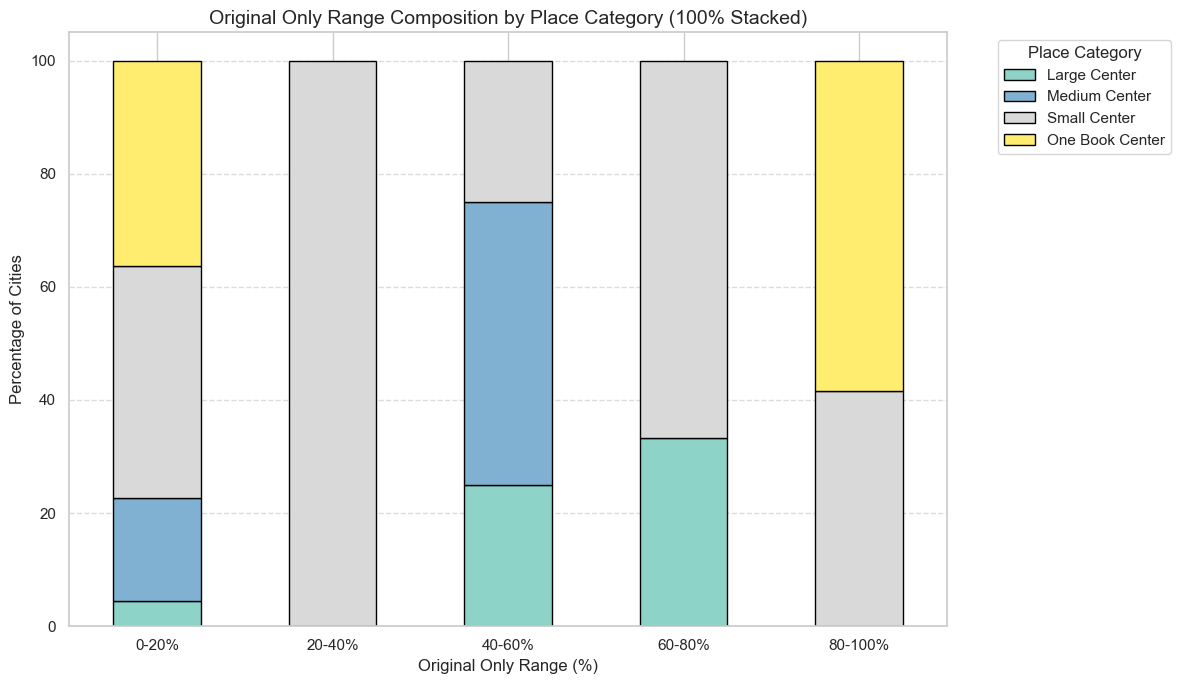

In [24]:
# 11c. Frequency Distribution: Original Only Range Mix (100% Stacked)
cat_dist_orig = dist_df_orig.groupby(['Original Only Range', 'place_category'], observed=True).size().unstack(fill_value=0)
cat_dist_orig_pct = cat_dist_orig.div(cat_dist_orig.sum(axis=1), axis=0) * 100

plt.figure(figsize=(12, 7))
cat_dist_orig_pct.plot(kind='bar', stacked=True, edgecolor='black', colormap='Set3', ax=plt.gca())
plt.title('Original Only Range Composition by Place Category (100% Stacked)', fontsize=14)
plt.xlabel('Original Only Range (%)', fontsize=12)
plt.ylabel('Percentage of Cities', fontsize=12)
plt.legend(title='Place Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [25]:
# 11d. Summary List of Cities by Original Only Range
display_cols = ['Original Only Range', 'place', 'place_category', 'Original Only (%)', 'Total Editions']
summary_list_orig = dist_df_orig[display_cols].sort_values(['Original Only Range', 'Original Only (%)'], ascending=[False, False])
with pd.option_context('display.max_rows', None, 'display.width', 1000):
    from IPython.display import display
    display(summary_list_orig)

classification,Original Only Range,place,place_category,Original Only (%),Total Editions
18,80-100%,Dijon,Small Center,100.00,2
21,80-100%,Sine loco,Small Center,100.00,2
23,80-100%,Bologna,Small Center,100.00,1
24,80-100%,Lemgo,Small Center,100.00,1
25,80-100%,Madrid,Small Center,100.00,1
29,80-100%,Coimbra,One Book Center,100.00,1
30,80-100%,Ferrara,One Book Center,100.00,1
32,80-100%,Heidelberg,One Book Center,100.00,1
36,80-100%,Mexico City,One Book Center,100.00,1
37,80-100%,Neustadt an der Weinstraße,One Book Center,100.00,1


## 12. Frequency Distribution of Both (Original & Commentary) Concentration
This section analyzes the distribution of cities based on their percentage of editions containing both Original and Commentary parts.

In [26]:
# 12a. Frequency Distribution: Number of Cities per Both % Range
dist_df_both = city_summary.copy().reset_index()
bins = [0, 20, 40, 60, 80, 100]
labels = ['0-20%', '20-40%', '40-60%', '60-80%', '80-100%']
dist_df_both['Both Range'] = pd.cut(dist_df_both['Both (%)'], bins=bins, labels=labels, include_lowest=True)

range_counts_both_simple = dist_df_both.groupby('Both Range', observed=True).size()

plt.figure(figsize=(10, 6))
range_counts_both_simple.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Frequency Distribution: Number of Cities per Both % Range (All Cities)', fontsize=14)
plt.xlabel('Both Range (%)', fontsize=12)
plt.ylabel('Number of Cities', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


KeyError: 'Both (%)'

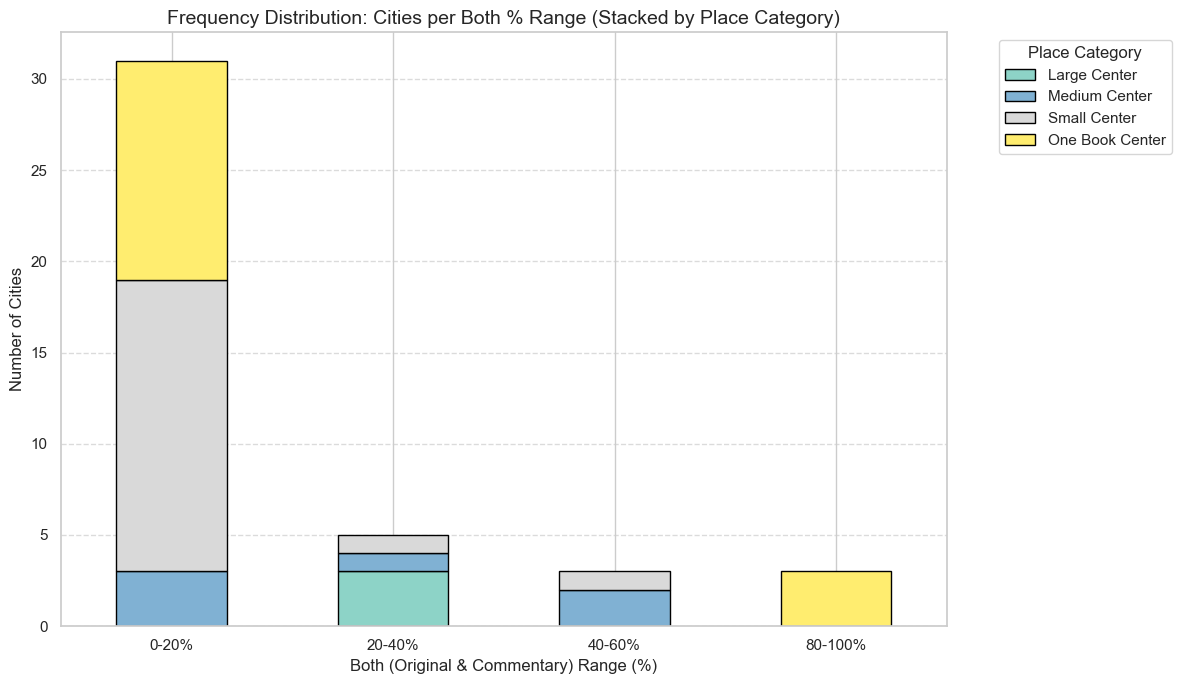

In [27]:
# 12b. Frequency Distribution: Cities per 'Both' % Range
dist_df_both = city_summary.copy().reset_index()
bins = [0, 20, 40, 60, 80, 100]
labels = ['0-20%', '20-40%', '40-60%', '60-80%', '80-100%']
dist_df_both['Both Range'] = pd.cut(dist_df_both['Both (Original & Commentary) (%)'], bins=bins, labels=labels, include_lowest=True)

range_counts_both = dist_df_both.groupby(['Both Range', 'place_category'], observed=True).size().unstack(fill_value=0)

plt.figure(figsize=(12, 7))
range_counts_both.plot(kind='bar', stacked=True, edgecolor='black', colormap='Set3', ax=plt.gca())
plt.title('Frequency Distribution: Cities per Both % Range (Stacked by Place Category)', fontsize=14)
plt.xlabel('Both (Original & Commentary) Range (%)', fontsize=12)
plt.ylabel('Number of Cities', fontsize=12)
plt.legend(title='Place Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

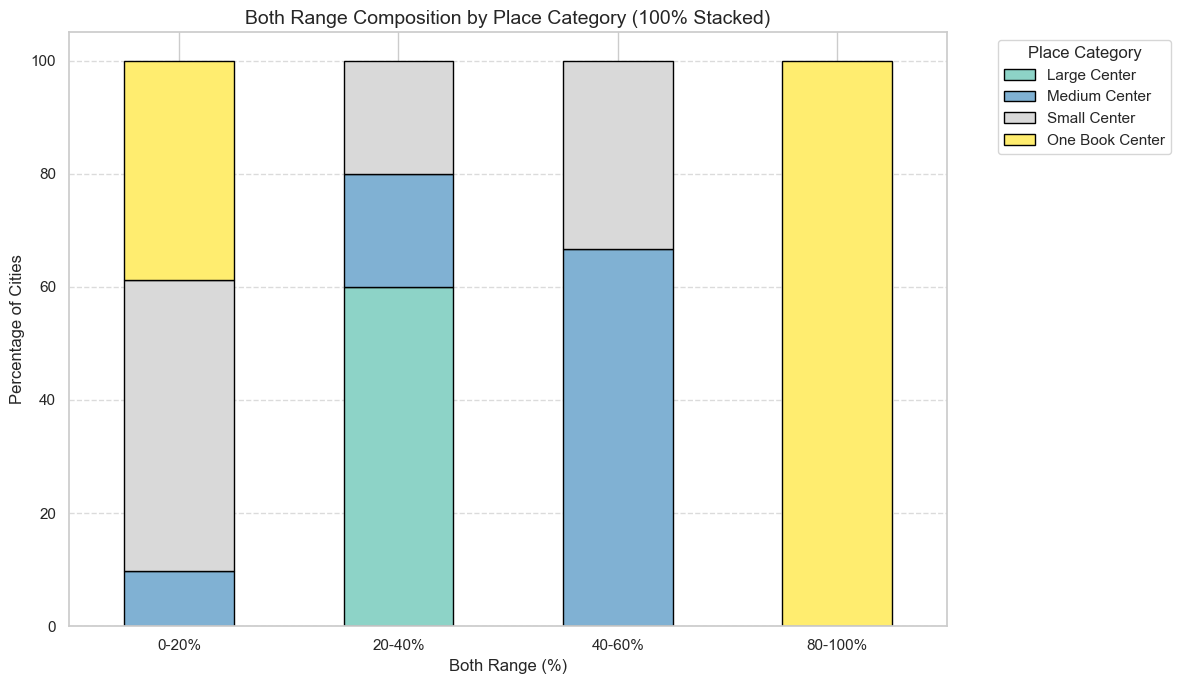

In [28]:
# 12c. Frequency Distribution: Both Range Mix (100% Stacked)
cat_dist_both = dist_df_both.groupby(['Both Range', 'place_category'], observed=True).size().unstack(fill_value=0)
cat_dist_both_pct = cat_dist_both.div(cat_dist_both.sum(axis=1), axis=0) * 100

plt.figure(figsize=(12, 7))
cat_dist_both_pct.plot(kind='bar', stacked=True, edgecolor='black', colormap='Set3', ax=plt.gca())
plt.title('Both Range Composition by Place Category (100% Stacked)', fontsize=14)
plt.xlabel('Both Range (%)', fontsize=12)
plt.ylabel('Percentage of Cities', fontsize=12)
plt.legend(title='Place Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [29]:
# 12d. Summary List of Cities by 'Both' Range
display_cols_both = ['Both Range', 'place', 'place_category', 'Both (Original & Commentary) (%)', 'Total Editions']
summary_list_both = dist_df_both[display_cols_both].sort_values(['Both Range', 'Both (Original & Commentary) (%)'], ascending=[False, False])
with pd.option_context('display.max_rows', None, 'display.width', 1000):
    from IPython.display import display
    display(summary_list_both)

classification,Both Range,place,place_category,Both (Original & Commentary) (%),Total Editions
28,80-100%,Avignon,One Book Center,100.00,1
34,80-100%,Leuven,One Book Center,100.00,1
35,80-100%,Mainz,One Book Center,100.00,1
3,40-60%,Antwerp,Medium Center,50.00,22
5,40-60%,Lyon,Medium Center,50.00,16
17,40-60%,Basel,Small Center,50.00,2
6,20-40%,Cologne,Medium Center,40.00,15
0,20-40%,Paris,Large Center,38.24,68
15,20-40%,Lisbon,Small Center,33.33,3
1,20-40%,Venice,Large Center,29.41,68


## 5. Image Count per Book (Ordered by Year of Print)
A bar chart showing the number of images in each of the 359 books in the corpus, sorted by the year of publication.

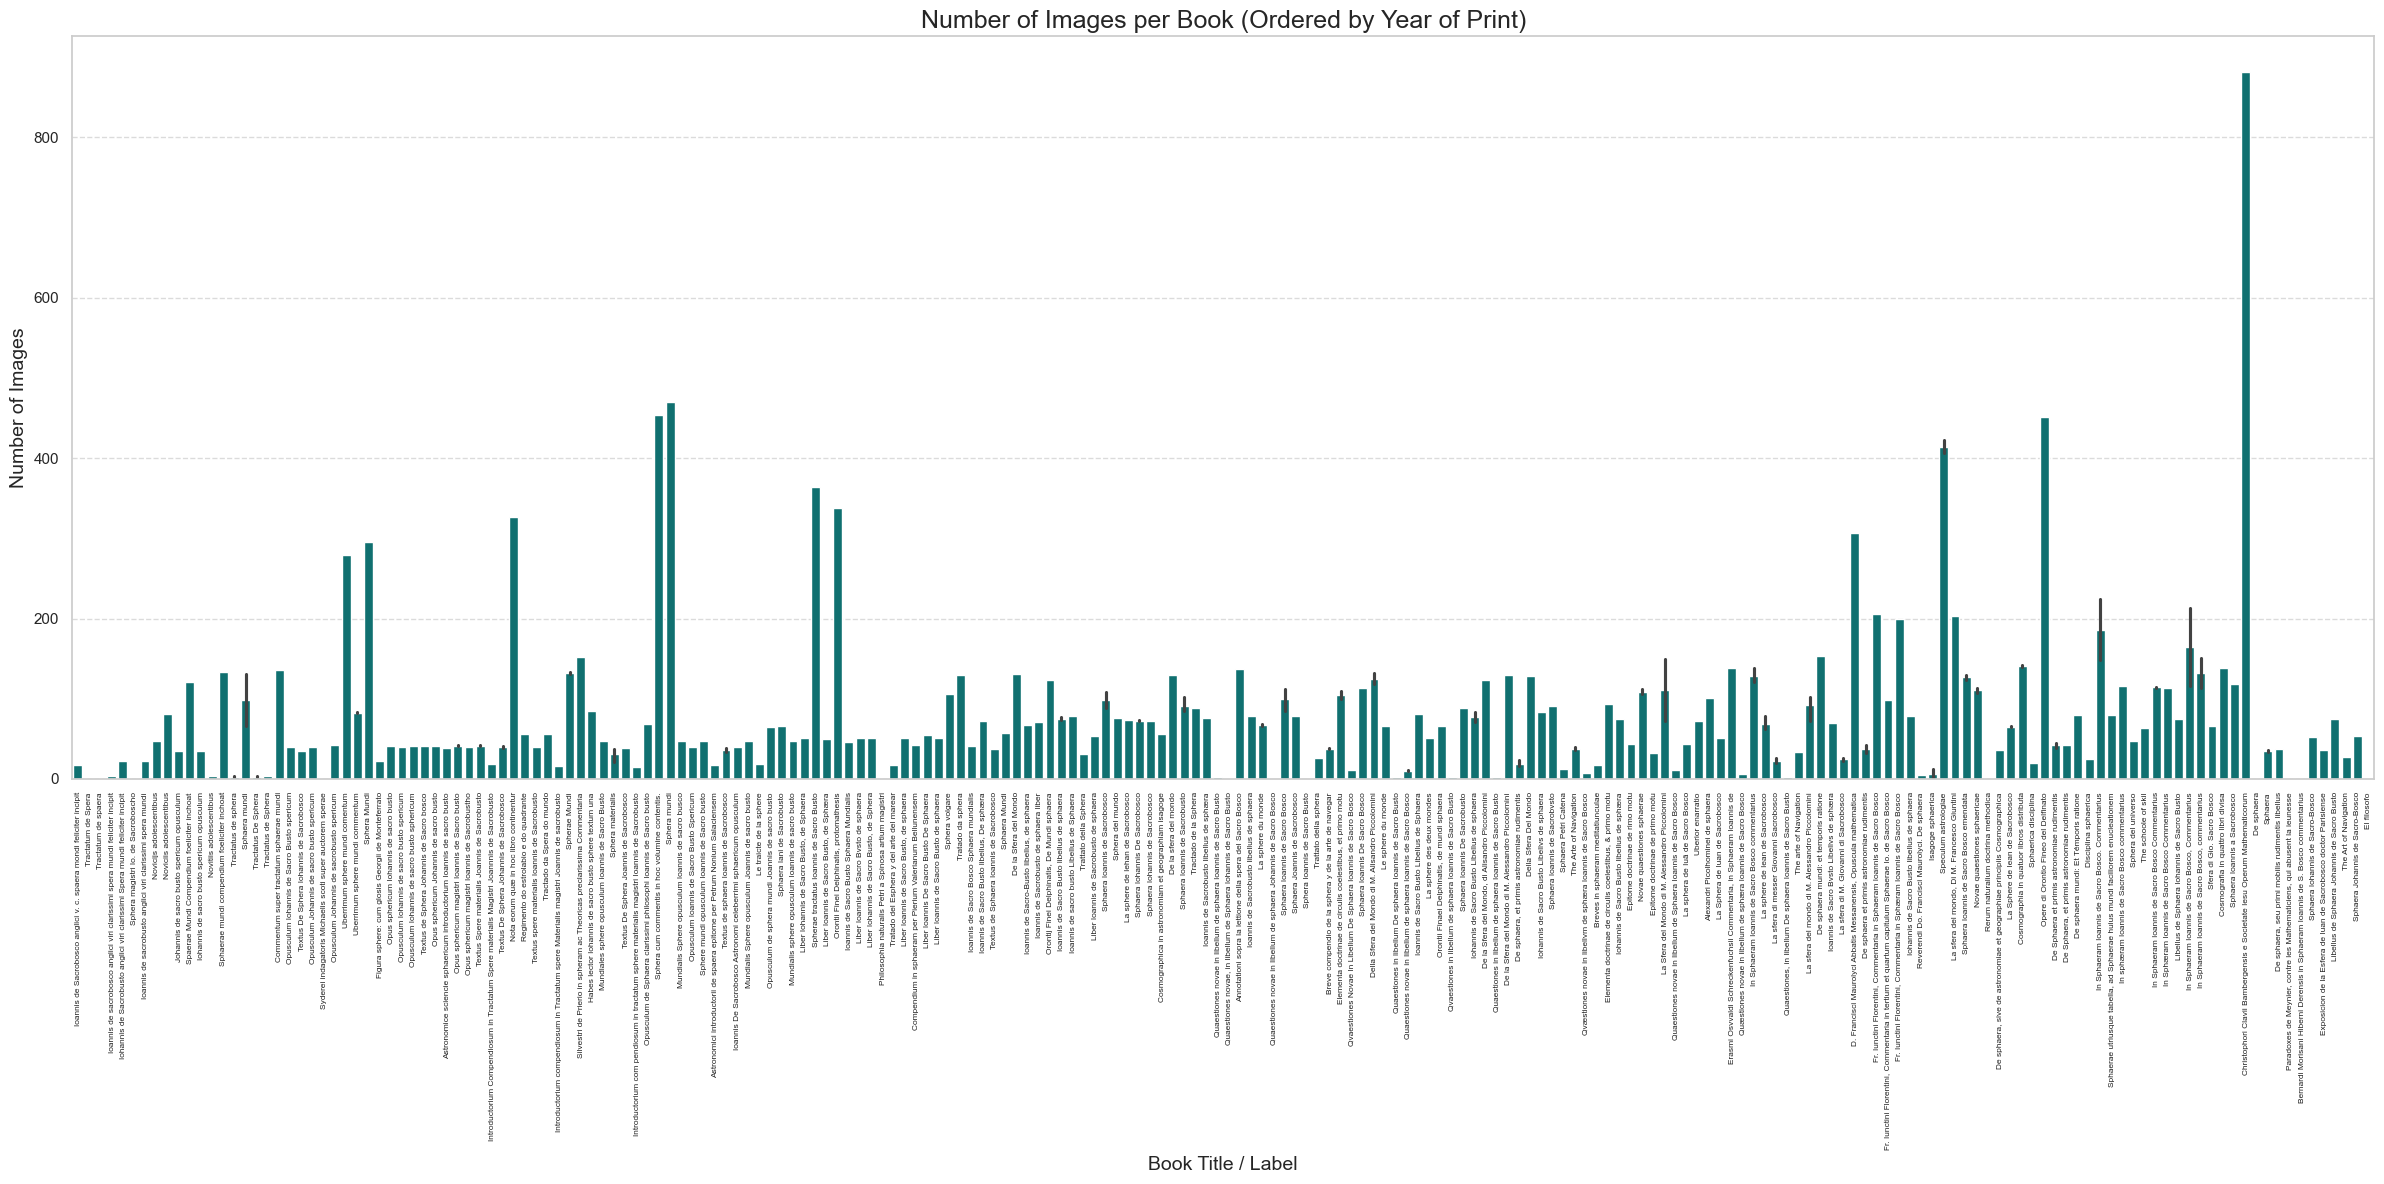

Total books plotted: 359


In [31]:
# Aggregate image counts per book
image_counts = image_df.groupby('bid').size().reset_index(name='image_count')

# Merge with book_df to get years and labels for all 359 books
# Ensure all books are included (even those with 0 images)
full_book_counts = pd.merge(book_df[['bid', 'label', 'year']], image_counts, on='bid', how='left').fillna(0)

# Sort by year, then by label for secondary ordering
full_book_counts = full_book_counts.sort_values(by=['year', 'label'])

# Plotting
plt.figure(figsize=(24, 12))
# Using sns.barplot; we'll use 'label' as the categorical x-axis
# Note: With 359 books, labels will be very dense.
ax = sns.barplot(data=full_book_counts, x='label', y='image_count', color='teal')

plt.title('Number of Images per Book (Ordered by Year of Print)', fontsize=18)
plt.xlabel('Book Title / Label', fontsize=14)
plt.ylabel('Number of Images', fontsize=14)

# Rotating labels and making them smaller for readability
plt.xticks(rotation=90, fontsize=6)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/corrections_round/images_per_all_books.png', dpi=300)

plt.show()

print(f"Total books plotted: {len(full_book_counts)}")
